In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x0 = 0.25
y0 = 0
t_max = 6.2832
n_steps = 10
dt = []
h = []
t = []
x_a = []
y_a = []
x_n = []
y_n = []
for i in range(6):
    dt.append(t_max / n_steps)
    h.append(1/dt[i])
    t.append(np.linspace(0, t_max, n_steps+1))
    x_a.append(x0 * np.cos(t[i]) - y0 * np.sin(t[i]))
    y_a.append(x0 * np.sin(t[i]) + y0 * np.cos(t[i]))
    file_name = "../output_files/circ_" + str(dt[i]) + ".csv"
    csv_data = np.loadtxt(file_name, delimiter=',')
    x_n.append(csv_data[:,1])
    y_n.append(csv_data[:,2])
    n_steps *= 2
np.set_printoptions(precision=4)

In [3]:

error = []
for i in range(6):
    N = t[i].shape[0]
    x_anal = x_a[i]
    x_num = x_n[i]
    y_anal = y_a[i]
    y_num = y_n[i]
    e = np.sqrt((x_anal - x_num)**2 + (y_anal - y_num)**2)
    error.append(np.sum(e)/N)

print(error)

[np.float64(0.4208423582499999), np.float64(0.17010098063234796), np.float64(0.0727217305643848), np.float64(0.03349553115244227), np.float64(0.01607029848003827), np.float64(0.007871053475753644)]


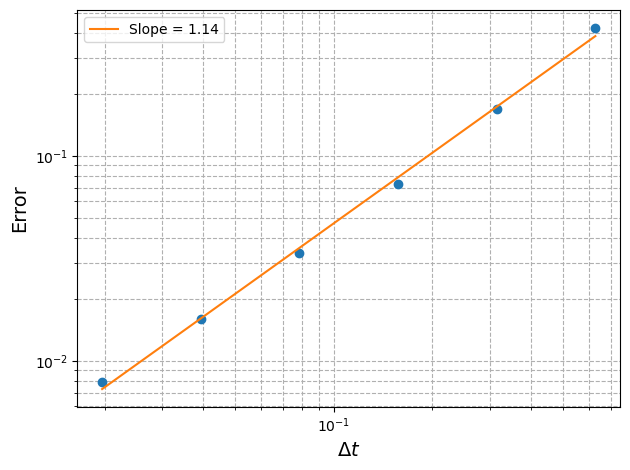

In [29]:
log_x = np.log10(dt)
log_y = np.log10(error)

coeffs = np.polyfit(log_x, log_y, 1)
slope, intercept = coeffs
a = 10**intercept
b = slope

# Power-law model
x_model = np.linspace(min(dt), max(dt), 100)
y_model = a * x_model**b

# Plot
plt.figure()
plt.loglog(dt, error, 'o')
#plt.loglog(x_model, y_model, '-', label=fr'Fit: $y = {a:.2f} x^{{{b:.2f}}}$')
plt.loglog(x_model, y_model, '-', label='Slope = 1.14')
plt.xlabel(r'$\Delta t$', fontsize='14')
plt.ylabel('Error', fontsize='14')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.savefig('convergence.png', dpi=400, bbox_inches='tight')
plt.show()

In [9]:
# Fit a linear polynomial (degree 1) to the data
slope, intercept = np.polyfit(log_dt, log_e,1)

# Print the slope
print(f'Slope: {slope}')

Slope: 1.143802378050399


In [ ]:
# MSE = [0] * 5
# sum_e_2 = [0] * 5
# for i in range(1):
#     N = t[i].shape[0]
#     x_anal = x_a[i]
#     x_num = x_n[i]
#     y_anal = y_a[i]
#     y_num = y_n[i]
#     for j in range(N):
#         e = (x_anal[j] - x_num[j])**2 + (y_anal[j] - y_num[j])**2
#         sum_e_2[i] += e
#     MSE[i] = 1/N * sum_e_2[i]

# print(MSE)

[np.float64(0.2886255078941344), 0, 0, 0, 0]


In [ ]:
dt = [0.62832, 0.31416, 0.019635]